In [2]:
import numpy as np
import dpluspy
import matplotlib.pyplot as plt 
import matplotlib 
import msprime
import demes
import moments
import pickle

matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.75
linewidth = 0.9

In [25]:
graph_file = "../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml"
model = dpluspy.inference.compute_bin_stats(
    graph_file, u=1.3e-8, sampled_demes=pop_ids, bins=np.array([0, 0.1]))

In [66]:
# bootstrap over heterozygosities

data = {}
for ii in range(1, 23):
    fname = f"../data/statistics/main/raw_sums/sums_Bherer_weighted_chr_{ii}.pkl"
    with open(fname, "rb") as fin:
        data.update(pickle.load(fin))
for x in data:
    data[x]["sums"] = data[x]["sums"][[-1]]
    data[x]["denoms"] = data[x]["denoms"][[-1]]
    data[x].pop("bins")

pop_ids_all = data[next(iter(data))]["pop_ids"]
pop_ids = pop_ids_all[:8]

pi_sums_all = [data[x]["sums"][0] for x in data]
pi_sums = np.array(dpluspy.bootstrapping.subset_means(
    pi_sums_all, pop_ids=pop_ids_all, to_pops=pop_ids))
pi_denoms = np.array([data[x]["denoms"][0] for x in data])
pi_samples = np.array(dpluspy.bootstrapping.get_bootstrap_reps(data))[:, 0]

In [76]:
def separate_stats(stats, pop_ids):
    # seperate out one/two-population stats.
    num_pops = len(pop_ids)
    one_pop = np.zeros(num_pops)
    two_pop = np.zeros(int(num_pops * (num_pops - 1) / 2))
    tally = 0
    for ii in range(num_pops):
        for jj in range(ii, num_pops):
            if ii == jj:
                one_pop[ii] = stats[tally]
            else:
                two_pop[tally - ii - 1] = stats[tally]
            tally += 1
    return one_pop, two_pop

pi_means = pi_sums.sum(0) / pi_denoms.sum(0)
pi_stds = np.var(pi_samples, axis=0) ** 0.5
H_means, div_means = separate_stats(pi_means, pop_ids)
H_stds, div_stds = separate_stats(pi_stds, pop_ids)
H_exp, div_exp = separate_stats(model[-1], pop_ids)

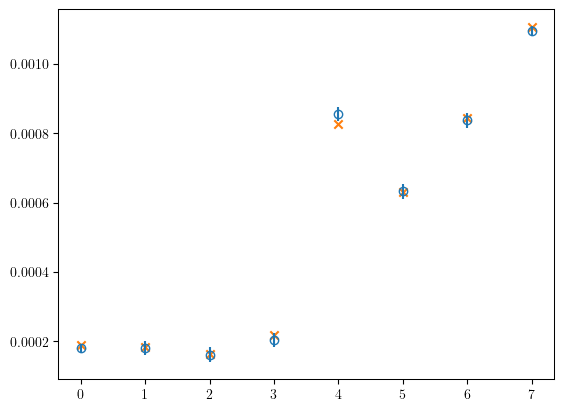

In [86]:
plt.errorbar(range(8), H_means, yerr=H_stds * 1.96, linestyle="none",
             marker="o", mfc="none")
plt.scatter(range(8), H_exp, color="tab:orange", marker="x")

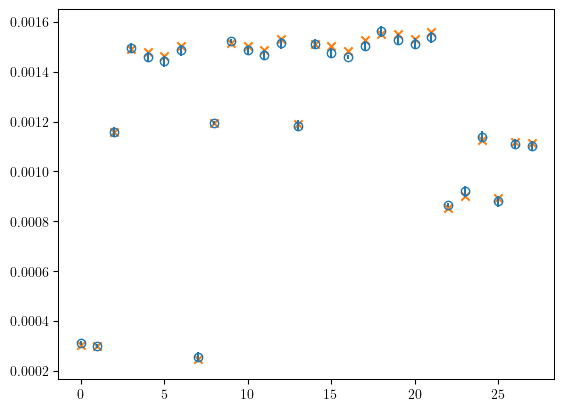

In [85]:
plt.errorbar(range(len(div_means)), div_means, yerr=div_stds * 1.96, linestyle="none",
             marker="o", mfc="none")
plt.scatter(range(len(div_means)), div_exp, color="tab:orange", marker="x")

In [118]:
def compute_f2(stats, pop_ids):

    num_pops = len(pop_ids)
    matrix = np.zeros((num_pops, num_pops))
    stat_names = dpluspy.utils._H_names(list(range(num_pops)))
    for ii in range(num_pops):
        matrix[ii, ii] = np.nan
        for jj in range(ii + 1, num_pops):
            H_X = stats[stat_names.index(f"H_{ii}_{ii}")]
            H_Y = stats[stat_names.index(f"H_{jj}_{jj}")]
            H_XY = stats[stat_names.index(f"H_{ii}_{jj}")]
            matrix[ii, jj] = matrix[jj, ii] = H_XY - (H_X + H_Y) / 2
    return matrix


f2_exp = model.F2_matrix()
for ii in range(len(pop_ids)):
    f2_exp[ii, ii] = np.nan
f2_mean = compute_f2(pi_means, pop_ids)
f2_samples = np.array([compute_f2(samp, pop_ids) for samp in pi_samples])
f2_var = np.var(f2_samples, axis=0)

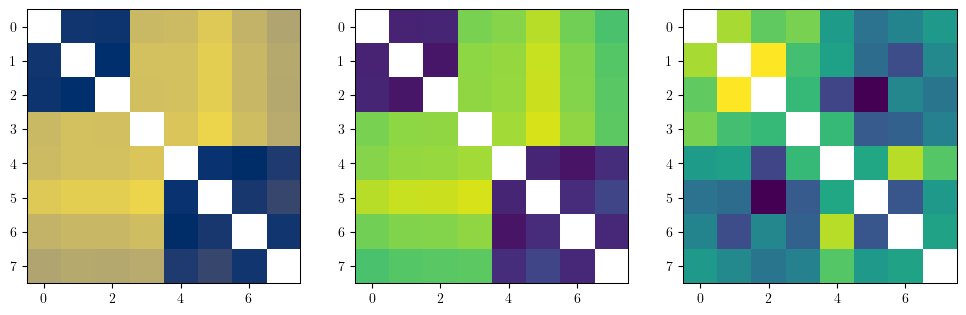

In [121]:
res = (f2_mean - f2_exp) / f2_var ** 0.5
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(f2_mean, vmin=0, vmax=0.0012, cmap="cividis")
axs[1].imshow(f2_exp, vmin=0, vmax=0.0012)
axs[2].imshow(res)

In [117]:
def zero_end_times(graph, targets):
    builder = graph.asdict()
    for deme in builder["demes"]:
        if deme["name"] in targets:
            deme["epochs"][-1]["end_time"] = 0
    builder = demes.Builder.fromdict(builder)
    return builder.resolve()

samples = [
    "Altai",
    "Vindija",
    "Chagyrskaya",
    "Denisova",
    "Stuttgart", 
    "Loschbour",
    "UstIshim",
    "Yoruba1"
]

In [33]:
graph = demes.load("../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml")
demog = msprime.Demography.from_demes(graph)
debug = demog.debug()
time_steps = np.linspace(0, 3e4, 50)
lineages = {
    "Altai": 2,
}
rates, surv = debug.coalescence_rate_trajectory(time_steps, lineages)

In [36]:
print(time_steps, surv)

[    0.           612.24489796  1224.48979592  1836.73469388
  2448.97959184  3061.2244898   3673.46938776  4285.71428571
  4897.95918367  5510.20408163  6122.44897959  6734.69387755
  7346.93877551  7959.18367347  8571.42857143  9183.67346939
  9795.91836735 10408.16326531 11020.40816327 11632.65306122
 12244.89795918 12857.14285714 13469.3877551  14081.63265306
 14693.87755102 15306.12244898 15918.36734694 16530.6122449
 17142.85714286 17755.10204082 18367.34693878 18979.59183673
 19591.83673469 20204.08163265 20816.32653061 21428.57142857
 22040.81632653 22653.06122449 23265.30612245 23877.55102041
 24489.79591837 25102.04081633 25714.28571429 26326.53061224
 26938.7755102  27551.02040816 28163.26530612 28775.51020408
 29387.75510204 30000.        ] [1.00000000e+000 1.12904076e-133 1.27473304e-266 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.0000000

In [3]:
def compute_rate_trajectory(graph, ts, samples):
    demog = msprime.Demography.from_demes(graph)
    debug = demog.debug()
    rates, _ = debug.coalescence_rate_trajectory(ts, samples)
    return rates

In [30]:
graph = demes.load("../models/full_model/round_6/fitted_models/full_model_round_6_Bherer_fit_13.yaml")

samples_times = {
    "Altai": 1.15e5,
    "Vindija": 4.5e4,
    "Chagyrskaya": 5.5e4,
    "Denisova": 6e4,
    "Stuttgart": 1e4, 
    "Loschbour": 1e4,
    "UstIshim": 4.5e4,
    "Yoruba1": 1e4
}


graph0 = zero_end_times(graph, list(samples_times.keys()))

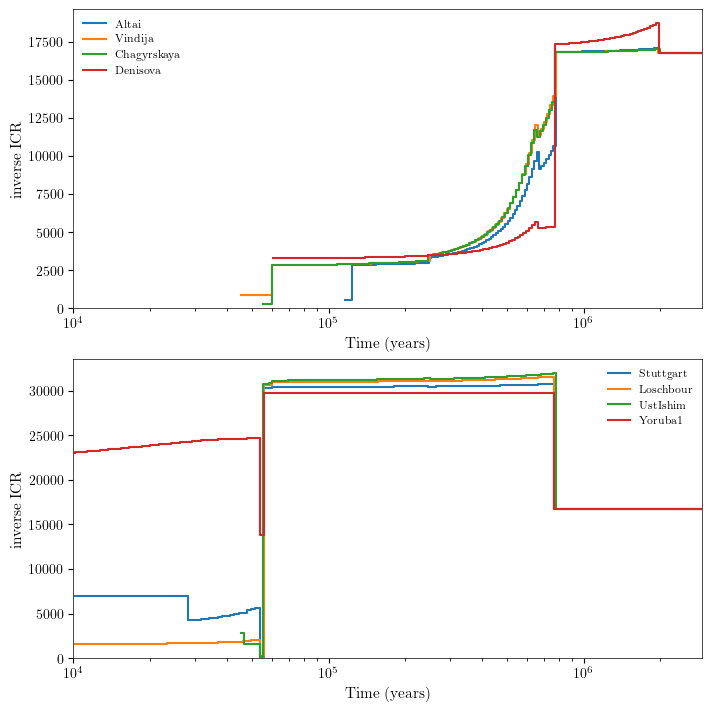

In [37]:
fig, axs = plt.subplots(2, 1, figsize=(7, 7), layout="constrained")

for ii, (sample, time) in enumerate(samples_times.items()):
    ax = axs.flat[ii // 4]
    min_t = np.log10(time / 29 * 1.01)
    ts = np.logspace(min_t, 5, 150)
    ys = compute_rate_trajectory(graph0, ts, {sample: 2})
    _ts = ts * 29
    ax.step(_ts, 1 / (2 * ys), label=sample)

for ax in axs.flat:
    ax.legend(framealpha=0)
    ax.set_ylim(0, )
    ax.set_xlim(1e4, _ts[-1])
    ax.set_xscale("log")
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("inverse ICR")

plt.savefig("figures/figS16.pdf")

In [13]:
graph1 = demes.load("files/full_model_edit.yaml")

samples_times = {
    "Altai": 1e4,
    "WN": 1e4,
    # "MH": 1e4,
    "Denisova": 1e4,
}

def zero_end_times(graph, targets):
    builder = graph.asdict()
    for deme in builder["demes"]:
        if deme["name"] in targets:
            deme["epochs"][-1]["end_time"] = 0
    builder = demes.Builder.fromdict(builder)
    return builder.resolve()


Text(0, 0.5, 'IRC')

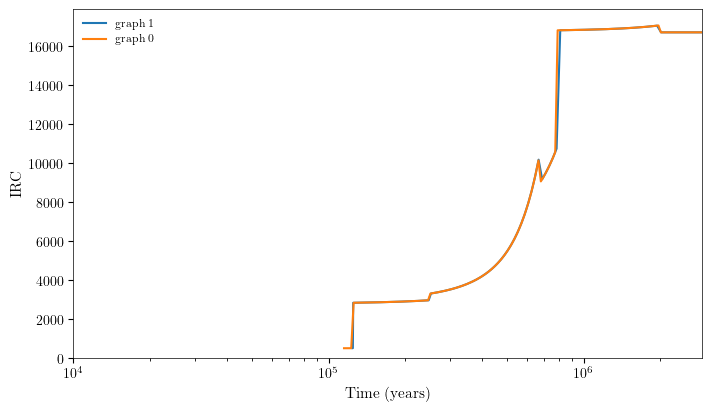

In [16]:
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")


ts = np.logspace(2.5, 5, 150)
ys = compute_rate_trajectory(graph1, ts, {"Altai": 2})
_ts = ts * 29 + 115000
ax.plot(_ts, 1 / (2 * ys), label="graph 1")


ts = np.logspace(np.log10(115000 / 29), 5, 150)
ys = compute_rate_trajectory(graph0, ts, {"Altai": 2})
_ts = ts * 29
ax.plot(_ts, 1 / (2 * ys), label="graph 0")

ax.legend(framealpha=0)
ax.set_ylim(0, )
ax.set_xlim(1e4, _ts[-1])
ax.set_xscale("log")
ax.set_xlabel("Time (years)")
ax.set_ylabel("IRC")

# plt.savefig("figures/figS16.pdf")